In [2]:
# At the very top of notebooks/1_data_extraction.ipynb
import sys, os
import pandas as pd
from datasets import Dataset, DatasetDict, load_from_disk
# Insert project_root (one level up) onto the import path
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))

import yaml


In [21]:
# import evaluate
# roc_auc = evaluate.load("evaluate-metric/roc_auc") 
print("HF_HUB_OFFLINE =", os.environ.get("HF_HUB_OFFLINE"))


HF_HUB_OFFLINE = None


In [22]:
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/GSM5652237_Liver-Hepatocytes-Z0000044M_chr1_basic_test")
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab.csv")

In [1]:
import pandas as pd
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab_without_min1.csv") 

In [3]:
# import numpy as np
# number_of_bins = 3
# variant_file_dataframe = df.dropna()
# max_val = variant_file_dataframe["std"].max()
# edges = list(np.linspace(0,max_val,number_of_bins + 1))
#     # labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]
# labels = []
# for i in range(len(edges) - 1):
#     labels.append(f"{edges[i]}-{edges[i+1]}")
# variant_file_dataframe["std_bin"] = pd.cut(
#         variant_file_dataframe["std"],                # your std-dev column
#         bins=edges,
#         labels=labels,
#         right=True,               # (a, b]
#         include_lowest=True  
#                 # include 0 in first bin
#         )
import sys,os
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))
from src.evaluator import predict_checkpoint

from datasets import Dataset, DatasetDict, load_from_disk
dataset = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_retrain_after_revert_without_-1_changed_bouond_condition_test")
# ds2 = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/3Q_retrain_revert_test_test")

res = predict_checkpoint(dataset,dataset,"regression_analysis",False,1,"InstaDeepAI","nucleotide-transformer-2.5b-multi-species","/sci/archive/michall/roeizucker/trained_huggingfacce_models_location/3Q_pretrain_after_revert_without_-1/epoch-1-step-32917")

2025-11-14 12:43:07.409785: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-14 12:43:10.078693: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-14 12:43:10.860173: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-14 12:43:14.983680: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-14 12:43:47.422205: W tensorflow/compiler/tf2

Loading model from: InstaDeepAI/nucleotide-transformer-2.5b-multi-species
with path: /sci/archive/michall/roeizucker/trained_huggingfacce_models_location/3Q_pretrain_after_revert_without_-1/epoch-1-step-32917


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [41]:
count = 0
for pred in res.predictions:
    if min(pred) < -0.05:
        count+=1
        # continue
len(res.predictions), count

(6599, 30)

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))
import yaml
import src.evaluator
import importlib
importlib.reload(src.evaluator)

from src.evaluator import perform_evaluation

# path = "/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/configs/config_cpg_evaluation.yaml"
path = "/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/configs/_test_without_minus1_new/eval_configs/GSM5652233_Liver-Hepatocytes-Z000000R3_epoch-1-step-41577_eval_test_without_minus1_new.yaml"
cfg = yaml.safe_load(open(path))
cfg["task"]["top_rows"] = 2000
cfg["paths"]["model_paths"] = [
    "/sci/archive/michall/roeizucker/trained_huggingfacce_models_location/3Q_pretrain_revert_test/epoch-1-step-33261"
    ]
# print(cfg)
results = perform_evaluation(cfg)
# df = pd.DataFrame(res, index=[0])
# df[df.columns]    
results


2025-11-10 12:30:35.564101: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-10 12:30:35.575195: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-10 12:30:35.578551: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-10 12:30:35.586886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 12:30:37.017224: W tensorflow/compiler/tf2

performing, evaluate_multiple_checkpoints task
for dataset: /sci/archive/michall/roeizucker/huggingface_datasets_dir/GSM5652233_Liver-Hepatocytes-Z000000R3_retrain_test_without_minus1_new_test
with model: InstaDeepAI nucleotide-transformer-2.5b-multi-species
finished loading dataset
loaded variant file
created variants bin based variant dictionary
mapping viable variants 450 / 498
finished creating variability positions dict
Evaluating model at path: /sci/archive/michall/roeizucker/trained_huggingfacce_models_location/GSM5652233_Liver-Hepatocytes-Z000000R3_pretrain_test_without_minus1_chr1-5/checkpoint-220000
Loading model from: InstaDeepAI/nucleotide-transformer-2.5b-multi-species
with path: /sci/archive/michall/roeizucker/trained_huggingfacce_models_location/GSM5652233_Liver-Hepatocytes-Z000000R3_pretrain_test_without_minus1_chr1-5/checkpoint-220000


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/cs/usr/roeizucker/new_storage/new_python_env/lib/python3.11/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


curr_bin: 0.0-0.23566666666666666
curr_bin: 0.23566666666666666-0.4713333333333333
curr_bin: 0.4713333333333333-0.707


,0.0-0.23566666666666666_pearsonr,0.0-0.23566666666666666_mse,0.0-0.23566666666666666_mae,0.23566666666666666-0.4713333333333333_pearsonr,0.23566666666666666-0.4713333333333333_mse,0.23566666666666666-0.4713333333333333_mae,0.4713333333333333-0.707_pearsonr,0.4713333333333333-0.707_mse,0.4713333333333333-0.707_mae,paths
0,0.020212,43.878333,0.548232,0.092062,409.381464,4.380608,0.165499,3317.954007,33.302723,/sci/archive/michall/roeizucker/trained_huggin...


In [2]:
results

,0.0-0.23566666666666666_pearsonr,0.0-0.23566666666666666_mse,0.0-0.23566666666666666_mae,0.23566666666666666-0.4713333333333333_pearsonr,0.23566666666666666-0.4713333333333333_mse,0.23566666666666666-0.4713333333333333_mae,0.4713333333333333-0.707_pearsonr,0.4713333333333333-0.707_mse,0.4713333333333333-0.707_mae,paths
0,0.161444,43.314796,0.553287,0.39279,400.777202,4.378671,0.161797,3257.036487,33.102943,/sci/archive/michall/roeizucker/trained_huggin...


In [3]:
results

,0.0-0.23566666666666666_pearsonr,0.0-0.23566666666666666_mse,0.0-0.23566666666666666_mae,0.23566666666666666-0.4713333333333333_pearsonr,0.23566666666666666-0.4713333333333333_mse,0.23566666666666666-0.4713333333333333_mae,0.4713333333333333-0.707_pearsonr,0.4713333333333333-0.707_mse,0.4713333333333333-0.707_mae,paths
0,0.041564,61.688247,0.777884,0.111868,312.32187,3.433682,0.053495,3515.284377,35.197828,/sci/archive/michall/roeizucker/trained_huggin...


In [ ]:
import pandas as pd
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab_without_min1.csv")
 

In [8]:
df.dropna()["std"].describe()

count    2.810344e+07
mean     7.155816e-02
std      6.610298e-02
min      0.000000e+00
25%      3.130000e-02
50%      5.057000e-02
75%      8.860000e-02
max      7.070000e-01
Name: std, dtype: float64

In [46]:
import pandas as pd
from datasets import Dataset, DatasetDict, load_from_disk

df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab_without_min1.csv")
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/GSM5652233_Liver-Hepatocytes-Z000000R3_pretrain_test_without_minus1_new_train")

In [49]:
import numpy as np
# na_positiosn = set(df[df["std"].isna()]["full_position"])
for row_num in range(len(ds)):
    if row_num % 5 == 0:
        print(row_num,end="\r")
    win_id = (ds[row_num]["window_id"])
    start = ds[row_num]["start"]
    bad_locatiosn = list((df[(df["window_id"] == win_id) & (df["std"].isna())]["full_position"].str.split(":").str[1].str.split("-").str[0].astype(int) - start) // 6)
    for loc in bad_locatiosn:
        if ds[row_num]["labels"][loc] != -100:
            print(ds[row_num]["labels"][loc])
    # break

KeyboardInterrupt: 

In [43]:
len(ds[0]["labels"])

901

In [2]:
import torch
import sys, os

# check checkpoint
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))

from src.utils.model_utils import get_fine_tuned_model
model = get_fine_tuned_model(False, 1, "InstaDeepAI/tide-transformer-2.5b-multi-species",
                             "/sci/archive/michall/roeizucker/trained_huggingfacce_models_location/3Q_pretrain_test_grad_norm_without_fp_or_variability_change/checkpoint-500/"
                             )
import torch

bad = []
with torch.no_grad():
    for n, p in model.named_parameters():
        if getattr(p, "is_meta", False) or p.device.type == "meta":
            # print(f"skip meta: {n} {tuple(p.shape)}")
            continue
        # use .any().item() only on non-meta tensors
        if torch.isnan(p).any().item() or torch.isinf(p).any().item():
            bad.append(n)

print("has_bad_params:", bool(bad))
print("examples:", bad[:8])



Loading model from: InstaDeepAI/tide-transformer-2.5b-multi-species
with path: /sci/archive/michall/roeizucker/trained_huggingfacce_models_location/3Q_pretrain_test_grad_norm_without_fp_or_variability_change/checkpoint-500/


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


has_bad_params: False
examples: []


In [4]:
len(bad)

0

In [ ]:
len(bad)

34

In [ ]:
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/GSM5652233_Liver-Hepatocytes-Z000000R3_pretrain_2.5param_chr5_no_lora_filter_variants_train")
all_labels = []
for i in range(len(ds)):
    all_labels.extend(ds[i]["labels"])



71331


print((all_labels).count(-100))

In [18]:
print((all_labels).count(-1))

71331


In [36]:
df = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_train2025-10-1313:43:15.994775.csv")

In [43]:
set(df["labels"][5].strip("[]").split((", ")))

# df["labels"][5]   

{'-100',
 '0.0',
 '0.1429443359375',
 '0.1910400390625',
 '0.285888671875',
 '0.3701171875',
 '0.3779296875',
 '0.385009765625',
 '0.492919921875',
 '0.5',
 '0.55078125',
 '0.56396484375',
 '0.615234375',
 '0.6728515625',
 '0.72216796875',
 '0.794921875',
 '0.7998046875',
 '0.84619140625'}

In [5]:
results

,0.0822-0.1096_pearsonr,0.0822-0.1096_mse,0.0822-0.1096_mae,0.0548-0.0822_pearsonr,0.0548-0.0822_mse,0.0548-0.0822_mae,0.0274-0.0548_pearsonr,0.0274-0.0548_mse,0.0274-0.0548_mae,0.1096-0.137_pearsonr,...,0.0-0.0274_pearsonr,0.0-0.0274_mse,0.0-0.0274_mae,0.3014-0.3288_pearsonr,0.3014-0.3288_mse,0.3014-0.3288_mae,0.4658-0.4932_pearsonr,0.4658-0.4932_mse,0.4658-0.4932_mae,paths
0,0.472000,0.040848,0.147953,0.465300,0.033928,0.128625,0.544394,0.023406,0.110635,0.384653,...,0.466415,0.118497,0.161238,0.457211,0.289334,0.424549,-1.0,1.621679,1.010840,/sci/archive/michall/roeizucker/trained_huggin...
1,0.479583,0.041672,0.148429,0.475646,0.033630,0.125843,0.565167,0.021344,0.101653,0.375774,...,0.444374,0.119506,0.150773,0.357817,0.302714,0.434213,-1.0,1.641915,1.000571,/sci/archive/michall/roeizucker/trained_huggin...
2,0.478005,0.042248,0.149391,0.475691,0.033738,0.125293,0.564249,0.020923,0.099173,0.374025,...,0.445527,0.119455,0.147681,0.352318,0.305844,0.437523,-1.0,1.648188,1.000652,/sci/archive/michall/roeizucker/trained_huggin...
3,0.477934,0.042656,0.149945,0.475644,0.033841,0.125001,0.563946,0.020637,0.097435,0.374307,...,0.445817,0.119427,0.145438,0.353897,0.308502,0.440198,-1.0,1.651893,1.000406,/sci/archive/michall/roeizucker/trained_huggin...


In [2]:
path = "/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab.csv"
df = pd.read_csv(path)

In [6]:
df

,Unnamed: 0,full_position,window_id,std,high_diff
0,0,chr1:10468-10470,chr1:5400-10800,0.10535,False
1,1,chr1:10470-10472,chr1:5400-10800,0.07760,False
2,2,chr1:10483-10485,chr1:5400-10800,0.05460,False
3,3,chr1:10488-10490,chr1:5400-10800,0.11940,False
4,4,chr1:10492-10494,chr1:5400-10800,0.14090,False
...,...,...,...,...,...
29401355,29401355,chrY:57216281-57216283,chrY:57213000-57218400,0.00000,False
29401356,29401356,chrY:57216333-57216335,chrY:57213000-57218400,0.40820,True
29401357,29401357,chrY:57216336-57216338,chrY:57213000-57218400,0.81640,True
29401358,29401358,chrY:57216341-57216343,chrY:57213000-57218400,0.81640,True


<Axes: >

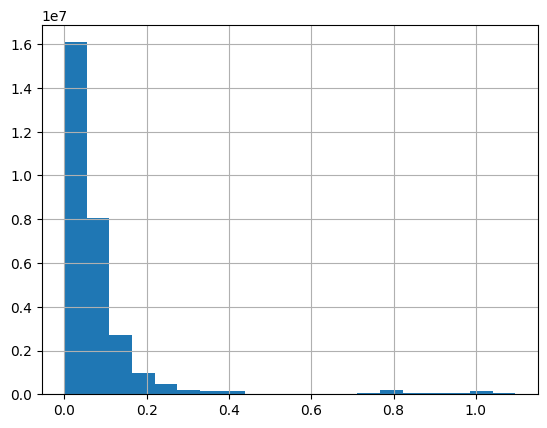

In [10]:
df["std"].hist(bins=20)

<Axes: >

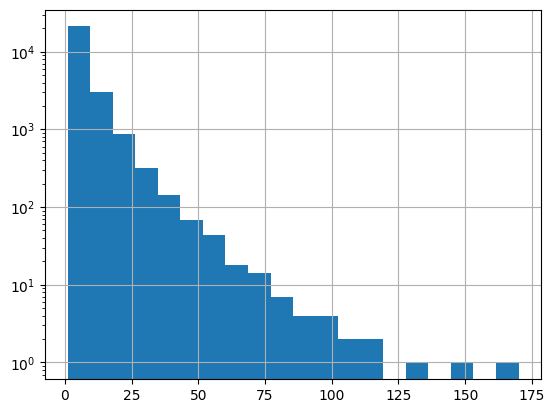

In [18]:
df[df["std"] > 1]["window_id"].value_counts().hist(bins=20,log=True)

In [72]:
results[[x[1] for x in sorted(zip(column_pos,results.columns)) if "mse" in x[1] or "paths" in x[1]]]

,paths,0.0-5.775_mse,5.775-11.55_mse,11.55-17.325000000000003_mse,17.325000000000003-23.1_mse,23.1-28.875_mse,28.875-34.650000000000006_mse,34.650000000000006-40.425000000000004_mse,40.425000000000004-46.2_mse,46.2-51.975_mse,51.975-57.75_mse
0,/sci/archive/michall/roeizucker/trained_huggin...,7.661500,87.904988,194.952672,235.833192,497.024444,609.870626,456.626711,590.804098,1338.274191,1998.013701
1,/sci/archive/michall/roeizucker/trained_huggin...,7.754282,88.027104,190.728550,221.311658,474.374958,589.641322,430.847445,569.836803,1305.299908,1969.444111
2,/sci/archive/michall/roeizucker/trained_huggin...,7.453824,86.215236,196.896816,243.920591,513.419982,621.444330,459.772883,610.975198,1366.877471,2016.976427
3,/sci/archive/michall/roeizucker/trained_huggin...,7.426579,85.903096,196.853115,244.074389,514.229588,621.371587,458.416705,612.929367,1369.844736,2016.785108
4,/sci/archive/michall/roeizucker/trained_huggin...,7.418704,85.842565,196.781256,243.954309,514.144626,621.094458,457.793900,613.147158,1370.340591,2016.717904


In [ ]:
results[[x[1] for x in sorted(zip(column_pos,results.columns)) if "pearson" in x[1] or "paths" in x[1]]]

,paths,0.0-5.775_pearsonr,5.775-11.55_pearsonr,11.55-17.325000000000003_pearsonr,17.325000000000003-23.1_pearsonr,23.1-28.875_pearsonr,28.875-34.650000000000006_pearsonr,34.650000000000006-40.425000000000004_pearsonr,40.425000000000004-46.2_pearsonr,46.2-51.975_pearsonr,51.975-57.75_pearsonr
0,/sci/archive/michall/roeizucker/trained_huggin...,0.964708,0.949263,0.893389,0.863568,0.697415,0.625997,0.723167,0.544522,0.410981,0.237725
1,/sci/archive/michall/roeizucker/trained_huggin...,0.965359,0.950480,0.894294,0.865436,0.697758,0.629978,0.729650,0.542407,0.409461,0.241197
2,/sci/archive/michall/roeizucker/trained_huggin...,0.965305,0.950443,0.895320,0.866282,0.700866,0.628778,0.729389,0.544854,0.413208,0.236804
3,/sci/archive/michall/roeizucker/trained_huggin...,0.965406,0.950689,0.895674,0.866868,0.701612,0.629717,0.730813,0.544488,0.412966,0.236543
4,/sci/archive/michall/roeizucker/trained_huggin...,0.965436,0.950751,0.895770,0.867024,0.701827,0.630022,0.731199,0.544451,0.412919,0.236511


In [ ]:
results[[x for x in sorted(results.columns) if "pearson" in x]]

,0.0-5.775_pearsonr,11.55-17.325000000000003_pearsonr,17.325000000000003-23.1_pearsonr,23.1-28.875_pearsonr,28.875-34.650000000000006_pearsonr,34.650000000000006-40.425000000000004_pearsonr,40.425000000000004-46.2_pearsonr,46.2-51.975_pearsonr,5.775-11.55_pearsonr,51.975-57.75_pearsonr
0,0.955269,0.853703,0.832576,0.656709,0.771538,0.725410,0.724786,0.444248,0.923627,0.473279
1,0.955857,0.854335,0.831921,0.658645,0.771345,0.723848,0.718102,0.437254,0.925332,0.485738
2,0.955671,0.854952,0.831596,0.657637,0.772966,0.730905,0.725443,0.447201,0.923617,0.471013
3,0.955755,0.855164,0.831354,0.657659,0.773705,0.731810,0.725003,0.448148,0.923740,0.471031
4,0.955776,0.855223,0.831300,0.657666,0.773880,0.731965,0.724903,0.448463,0.923773,0.471080


In [19]:
# import os
# import pandas as pd
# results_path = "/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/results"
# relevant = [x for x in os.listdir(results_path) if "chr5_no_lor" in x]
# for directory in relevant:
#     rel_file_path = os.path.join(directory,"resilt.csv")
#     file_path = os.path.join(results_path,rel_file_path)
#     df = pd.read_csv(file_path)
#     column_pos = list(df.columns.str.split(".").str[0][:-1].astype(int)) + [-1]
#     df = df[[x[1] for x in sorted(zip(column_pos,df.columns)) if "mse" in x[1] or "paths" in x[1]]]
#     df["mod"] = df["paths"].str.split("/").str[-1]
#     df = df.drop("paths",axis=1)
#     print(directory)
#     print(df)

# # df = pd.read_csv("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/results/GSM5652235_Liver-Hepatocytes-Z0000043Q_epoch-1-step-83153_eval_7.5param_chr5_no_lora/resilt.csv")
# # # df = results
# # column_pos = list(df.columns.str.split(".").str[0][:-1].astype(int)) + [-1]
# # df[[x[1] for x in sorted(zip(column_pos,df.columns)) if "mse" in x[1] or "paths" in x[1]]].to_csv("delete_me1.csv")

In [ ]:
import pandas as pd
# prediction = predict_checkpoint(ds,ds,"regression_analysis",False,1,"InstaDeepAI","nucleotide-transformer-2.5b-multi-species","/sci/archive/michall/roeizucker/trained_huggingfacce_models_location/GSM5652234_Liver-Hepatocytes-Z000000T3_pretrain_2.5param_chr5_no_lora_filter_variants/checkpoint-155000")
df = pd.read_csv("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/results/GSM5652233_Liver-Hepatocytes-Z000000R3_epoch-1-step-83153_eval_7.5param_chr5_no_lora/resilt.csv")
# df = results
column_pos = list(df.columns.str.split(".").str[0][:-1].astype(int)) + [-1]
df[[x[1] for x in sorted(zip(column_pos,df.columns)) if "pear" in x[1] or "paths" in x[1]]].to_csv("delete_me_pear_old.csv")

In [24]:
curr_df = df[[x for x in df.columns if "pearson" in x or "paths" in x]]
curr_df["stage"] = curr_df["paths"].str.split("/").str[-2:-1]
curr_df.drop("paths",axis=1)

/tmp/ipykernel_99743/3764126966.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_df["stage"] = curr_df["paths"].str.split("/").str[-2:-1]


,0.0-0.36533333333333334_pearsonr,0.36533333333333334-0.7306666666666667_pearsonr,0.7306666666666667-1.096_pearsonr,stage
0,0.887603,0.670099,0.305077,[GSM5652235_Liver-Hepatocytes-Z0000043Q_pretra...
1,0.891396,0.656090,0.311939,[GSM5652235_Liver-Hepatocytes-Z0000043Q_epoch-...
2,0.894537,0.639455,0.299224,[GSM5652235_Liver-Hepatocytes-Z0000043Q_epoch-...
3,0.886499,0.655971,0.327043,[GSM5652235_Liver-Hepatocytes-Z0000043Q_epoch-...


In [ ]:
import pandas as pd
final_results = []
for i in range(len(results)):
    model_results = {}
    keys = []
    for bin_value in results[i]:
        bin_name = bin_value[0]
        for val in bin_value[1:]:
            key = list(val)[0]
            value = val[key]
            model_results[bin_name+"_"+key]= value
            keys.append(bin_name+"_"+key)
    final_results.append(model_results)
pd.DataFrame( final_results)

In [ ]:

from datasets import Dataset, DatasetDict, load_from_disk
import pandas as pd
import numpy as np
dataset = load_from_disk(cfg['paths']['dataset_path'])
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab.csv")
number_of_bins = 3
max_val = df["std"].max()
edges = list(np.linspace(0,max_val,number_of_bins + 1))
# labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]
labels = []
for i in range(len(edges) - 1):
    labels.append(f"{edges[i]}-{edges[i+1]}")
df["std_bin"] = pd.cut(
    df["std"],                # your std-dev column
    bins=edges,
    labels=labels,
    right=True,               # (a, b]
    include_lowest=True       # include 0 in first bin
)

In [ ]:
import evaluate
pearsonr = evaluate.load("pearsonr")
mse = evaluate.load("mse")
mae = evaluate.load("mae")

In [ ]:
curr_bin = "0.0-0.36533333333333334"
curr_dataset = 0


In [ ]:
for curr_bin in df["std_bin"].unique():
    labels_from_dataset = []
    labels_from_prediction = []
    for curr_dataset in range(len(results[0].predictions)):
        curr_window_id =dataset[curr_dataset]["window_id"] 
        limited_df = df[(df["std_bin"] == curr_bin) & (df["window_id"] == curr_window_id)]
        starts_of_viable = list(limited_df["full_position"].str.split(":").str[1].str.split("-").str[0].astype(int))
        range(dataset[curr_dataset]["start"],dataset[curr_dataset]["end"])
        viable_positions = [((x//6 * 6) - dataset[curr_dataset]["start"])//6 for x in starts_of_viable ]
        filtered_labels_from_dataset = [ dataset[curr_dataset]["labels"][i + 1] for i in viable_positions]
        labels_from_dataset.extend(filtered_labels_from_dataset)
        filtered_from_prediction = [ results[0].predictions[curr_dataset][i + 1][0] for i in viable_positions]
        labels_from_prediction.extend(filtered_from_prediction)
    res_r = pearsonr.compute(predictions=labels_from_prediction,references=labels_from_dataset)
    res_mse = mse.compute(predictions=labels_from_prediction,references=labels_from_dataset)
    res_mae = mae.compute(predictions=labels_from_prediction,references=labels_from_dataset)
    print(curr_bin,res_r,res_mse,res_mae)

In [ ]:
# df["std_bin"].unique
from scipy.stats import pearsonr

In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv("/sci/archive/michall/roeizucker/Tom_project/created_datasets/Liver-Hepatocytes_Kaplan_lab.csv")
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/GSM5652233_Liver-Hepatocytes-Z000000R3_chr1_basic_test")
df_intermediate = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_test2025-10-03 23:34:57.051321.csv")

In [ ]:
# len(set(ds["window_id"]).intersection(set(df["window_id"])))
specific_df = df[df["window_id"] == "chr1:151291800-151297200"]
labels = ds[0]["labels"]
full_position = ds[0]["full_position"]
print(len(full_position))
# df

In [ ]:
from src.utils.dataset_utils import dataset_generator_wrapper
new_dataset = Dataset.from_generator(dataset_generator_wrapper("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_test2025-10-03 23:34:57.051321.csv", 50)) 

In [ ]:
ds[0]["labels"].count(-100)

In [ ]:
start = new_dataset[0]["start"]
for i, bin_value in enumerate(new_dataset[0]["labels"][1:]):
    if bin_value != -100:
        print(bin_value,i*6 + start)

In [ ]:
df2 = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/temp_test2025-10-03 23:34:57.051321.csv")

In [ ]:
df2

In [ ]:
starts_of_viable = df2[df2["window_id"] == "chr1:151291800-151297200"]["starts"][0].strip("[]").split(", ")
values = df2[df2["window_id"] == "chr1:151291800-151297200"]["values"][0].strip("[]").split(", ")
(list(zip(starts_of_viable,values)))
    

In [ ]:
# final_results = []
# # TODO: find keys without them being constants
# keys = ['eval_loss', 'eval_mse', 'eval_mae', 'eval_pearson_r', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second']
# for path,checkpoint_result in zip(cfg['paths']['model_paths'],res):
#     path_result = {"path":path}
#     for bin, eval_result in checkpoint_result:
#         for key in keys:
#             path_result[bin + key] = eval_result[key]
#             # path_result.append(eval_result[key])
#     final_results.append(path_result)
#         # print(path,bin,list(eval_result)) 
#     # print(path,checkpoint_result[0])
# final_df = pd.DataFrame(final_results) 
# final_df
results.to_csv("delete_me.csv")

In [ ]:
import pandas as pd

path = "/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/results/cpg_test_retrain_all_rows/resilt.csv"

df = pd.read_csv(path)

In [ ]:
columns_dict = {}
for col in df.columns:
    first_num = col.split("-")[0]
    if first_num not in columns_dict:
        columns_dict[first_num] = []
    columns_dict[first_num].append(col)
for key in columns_dict:
    df[columns_dict[key]].to_csv(key + "result.csv")

In [ ]:
columns_dict = {}
for col in df.columns:
    metric = (col.split(".0")[-1])
    if metric not in columns_dict:
        columns_dict[metric] = []
    columns_dict[metric].append(col)
for key in columns_dict:
    df[columns_dict[key]].to_csv("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/"+key + "result.csv")

In [ ]:
import numpy as np
arr1 = np.linspace(0,100,4)
print(f"Array 1: {arr1}")


In [ ]:
results["checkpoint"] = results["paths"].str.strip("/").str.split('/').str[-1]
results

In [ ]:
# cfg = yaml.safe_load(open("../config_cpg_evaluation.yaml"))

analysis_name = cfg["task"]["analysis_name"]
res_path = os.path.join("results",analysis_name)
if not os.path.exists(res_path):
    os.mkdir(res_path)
results.to_csv(os.path.join(res_path,"resilt.csv"),index=None)

In [ ]:
# combine_results_section
res_path


In [ ]:
# df_combined

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

df1 = pd.read_csv("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/cpg_ENCFF713LYH_900_500m_top2000_train/resilt.csv")
df2 = pd.read_csv('/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/cpg_ENCFF713LYH_900_500m_top2000_on_ENCFF479QRW_test')
label_1 = "train"
label_2 = 'test_QRW'
df1["split"] = label_1
df2["split"] = label_2
df_combined = pd.concat([df1,df2])



df = df_combined
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Extract numeric checkpoint IDs
df["ckpt_num"] = df["checkpoint"].str.extract(r"checkpoint-(\d+)").astype(int)
df_sorted = df.sort_values("ckpt_num")

# Metrics and assigned colors
if cfg['task']["task_type"] == "cpg_evaluation":
    metrics = [("eval_pearson_r", "eval_pearson_r", "tab:blue")]
else:
    metrics = [
        ("eval_f1_class_0", "F1 Class 0", "tab:blue"),
        ("eval_f1_class_1", "F1 Class 1", "tab:orange"),
        ("eval_f1_class_2", "F1 Class 2", "tab:green"),
    ]

plt.figure(figsize=(9, 5))

for metric_col, metric_label, color in metrics:
    if metric_col not in df.columns:
        continue
    pivot = df_sorted.pivot_table(index="ckpt_num", columns="split", values=metric_col)
    if pivot.dropna(how="all").empty:
        continue
    
    # Train — solid
    if label_1 in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[label_1],
            marker="o",
            linestyle="-",
            color=color,
            label=f"{label_1} {metric_label}"
        )
        
    # Test — dotted
    if label_2 in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[label_2],
            marker="o",
            linestyle=":",
            color=color,
            label=f"{label_2} {metric_label}"
        )
plt.xlabel("Checkpoint")

if cfg['task']["task_type"] == "cpg_evaluation":
    plt.ylabel("pearson_r")
    plt.title("pearson_r over Checkpoints")
else:
    plt.ylabel("F1 Score")
    plt.title("F1 Scores (Classes 0 – 2) over Checkpoints")
plt.xticks(pivot.index, [str(x) for x in pivot.index], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# def check_predictions_for_selected_label(predictions, labels, dataset, tested_index):
#     curr_dataset = dataset.select([tested_index])
#     # to_predict = labels[tested_index] != cfg['model']['blank_label']
#     to_predict = labels[tested_index] != -100
#     predictions_masked = (predictions[tested_index].flatten()[to_predict])
#     labels_masked = labels[tested_index].flatten()[to_predict]

#     bads = 0
#     goods = 0
#     for i in range(len(predictions_masked)):
#         if abs(predictions_masked[i] - labels_masked[i]) > 10:
#             # print(f"Warning: prediction {predictions_masked[i]} does not match label {labels_masked[i]} at index {i}")
#             # print(f"Difference: {abs(predictions_masked[i] - labels_masked[i])}")
#             bads += 1
#         elif predictions_masked[i] > 30:
#             # print("good")
#             goods += 1
#     ratio = bads / (bads + goods) if (bads + goods) > 0 else 0
#     print(f"bads: {bads}, goods: {goods}, ratio: {ratio}")
#     # print(ratio)
#     # if (ratio > 0.9 or ratio < 0.1) and (bads + goods > 10):
#     #     if bads > goods:
#     #         print('bad',end=' ')
#     #     else:
#     #         print('good',end=' ')
#     #     # break
#     #     results_hist = [0]*11
#     #     for label in dataset[tested_index]["labels"]:
#     #         if label == -100:
#     #             results_hist[10]+=1
#     #             continue
#     #         index = int(label // 10)
#     #         results_hist[index] += 1
#     #     # print("hist",results_hist)
        


In [ ]:
# predictions = res[0]
# labels = res[1]
# dataset = load_from_disk(cfg['paths']['dataset_path'])
# tested_index = 0

# # for tested_index in range(len(predictions)):
# #     check_predictions_for_selected_label(predictions, labels, dataset, tested_index)
# check_predictions_for_selected_label(predictions, labels, dataset, 2)
#     # predictions = predictions[0] if isinstance(predictions, tuple) else predictions

In [ ]:
# cfg = yaml.safe_load(open("../config_cpg_evaluation.yaml"))


In [ ]:
# predictions = res[0]
# labels = res[1]
# dataset = load_from_disk(cfg['paths']['dataset_path'])

# tested_index = 0
# for tested_index in range(len(dataset)):
#     if tested_index % 1000 == 0:
#         print("Testing index:", tested_index,flush=True)
#     start_pos = dataset[tested_index]["start"]
#     end_pos = dataset[tested_index]["end"]
#     ranges = [
#         [3067203, 3071203],      # PRDM16 promoter/enhancer window
#         [24963138, 24967138],    # RUNX3 promoter window
#         [61080621, 61084621],    # NFIA promoter/intronic sentinel window :contentReference[oaicite:0]{index=0}
#         [65790895, 65794895],    # PDE4B promoter window :contentReference[oaicite:1]{index=1}
#         [119421765, 119425765],  # TBX15 promoter window
#         [206770494, 206774494]   # IL10 promoter window :contentReference[oaicite:2]{index=2}
#     ]
#     for val in ranges:
#         if (start_pos <= val[0] and end_pos >= val[0]) or (start_pos <= val[1] and end_pos >= val[1]) or \
#             (start_pos <= val[0] and end_pos >= val[1]) :
#             check_predictions_for_selected_label(predictions, labels, dataset, tested_index)


In [ ]:
# predictions = res[0]
# labels = res[1]
# dataset = load_from_disk(cfg['paths']['dataset_path'])
# tested_index = 0
# for tested_index in range(0,len(dataset)):
#     if tested_index % 1000 == 0:
#         print("Testing index:", tested_index,flush=True)
#     start_pos = dataset[tested_index]["start"]
#     end_pos = dataset[tested_index]["end"]
#     if start_pos < 3067203 and start_pos > 3007203:
#         print(start_pos, end_pos)
#         print("start_pos is less than 3067203 for index:", tested_index, "start_pos:", start_pos, "end_pos:", end_pos)
        

In [ ]:
# results_hist = [0]*11
# for label in dataset[553]["labels"]:
#     if label == -100:
#         results_hist[10]+=1
#         continue
#     index = int(label // 10)
#     results_hist[index] += 1
# print(results_hist)

In [ ]:
# ranges = [
#     [3067203, 3071203],      # PRDM16 promoter/enhancer window
#     [24963138, 24967138],    # RUNX3 promoter window
#     [61080621, 61084621],    # NFIA promoter/intronic sentinel window :contentReference[oaicite:0]{index=0}
#     [65790895, 65794895],    # PDE4B promoter window :contentReference[oaicite:1]{index=1}
#     [119421765, 119425765],  # TBX15 promoter window
#     [206770494, 206774494]   # IL10 promoter window :contentReference[oaicite:2]{index=2}
# ]
# for start_pos, end_pos in zip(dataset["start"], dataset["end"]):
#     for range_val in ranges:
#         if start_pos >= range_val[0] and start_pos <= range_val[1] or \
#            end_pos >= range_val[0] and end_pos <= range_val[1] :
#             print("hit", start_pos, range_val)
    